# Strategy Research Walkthrough

Build, backtest, and analyze a momentum strategy from scratch using `quant.engine`.

In [4]:
import sys
sys.path.append("..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from engine import Strategy, Signal, Engine, BacktestConfig, DataFrameSource, summary
from engine.report import generate
from engine.walkforward import WalkForward
from engine.risk.stop_loss import StopLoss
from engine.risk.exposure import ExposureLimit

os.environ["QUANT_API_URL"] = "https://quant-query-api-324202484543.asia-east2.run.app"
# os.environ["QUANT_GCS_BUCKET"] = "deductive-notch-495015-c2-quant-data"
plt.rcParams["figure.figsize"] = (12, 4)

print("Engine ready.")

Engine ready.


## 1. Load Real Data from GCS

Multi-year US stock daily bars from the GCS backfill.

In [5]:
from quant import bars

# Load US stocks daily bars via Go Query API (no GCS DNS dependency)
# symbols = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META"]
symbols = ["BTCUSDT"]

df = bars(
    symbols,
    start="2026-05-13",
    end="2026-05-14",
    market="crypto",
    source="api",
)
print(f"Rows: {len(df)}, Symbols: {df.index.get_level_values('symbol').unique().tolist()}")

close = df["close"].unstack("symbol")
print(f"Shape: {close.shape} (~{close.shape[0]} trading days × {close.shape[1]} symbols)")
close.head()

Rows: 97, Symbols: ['BTCUSDT']
Shape: (97, 1) (~97 trading days × 1 symbols)


symbol,BTCUSDT
timestamp,
2026-05-13 16:00:00+00:00,78906.76
2026-05-13 16:05:00+00:00,78763.55
2026-05-13 16:10:00+00:00,78922.12
2026-05-13 16:15:00+00:00,78912.01
2026-05-13 16:20:00+00:00,78991.16


## 2. Define a Momentum Strategy

Buy top-N momentum stocks, rebalance monthly.

In [15]:
class MomentumStrategy(Strategy):
    lookback: int = 60        # 60-day momentum
    top_n: int = 2            # Hold top 2 stocks
    rebalance_days: int = 21  # Rebalance every 21 bars (~monthly)

    def on_init(self, ctx):
        self.bars_since_rebalance = 0

    def on_bar(self, ctx, bar):
        self.bars_since_rebalance += 1
        # Not enough history yet — wait for lookback window
        if bar < self.lookback:
            return []
        if self.bars_since_rebalance < self.rebalance_days:
            return []

        # Compute momentum for each symbol as a Series
        momentum = (ctx.data.close.iloc[bar] / ctx.data.close.iloc[bar - self.lookback]) - 1
        if hasattr(momentum, "nlargest"):
            top = momentum.nlargest(self.top_n).index.tolist()
        else:
            top = [ctx.universe[0]]  # Single-symbol fallback

        signals = []
        for sym in ctx.universe:
            if ctx.portfolio.has_position(sym) and sym not in top:
                signals.append(Signal.close(sym))
        for sym in top:
            if not ctx.portfolio.has_position(sym):
                signals.append(Signal.target(sym, weight=1.0 / self.top_n))

        self.bars_since_rebalance = 0
        return signals

print(f"Parameters: {MomentumStrategy().parameters()}")

Parameters: {'lookback': 60, 'top_n': 2, 'rebalance_days': 21}


## 3. Run Backtest

In [16]:
from engine.data import DataFrameSource

data = DataFrameSource(close=close)
cfg = BacktestConfig(initial_capital=100_000, slippage_bps=5, commission_bps=1)
engine = Engine(cfg)
result = engine.run(MomentumStrategy(), data)

s = summary(result)
print(f"Strategy: {result.strategy_name}")
print(f"Total Return: {s['total_return']:.2%}")
print(f"Annual Return: {s['annual_return']:.2%}")
print(f"Sharpe Ratio: {s['sharpe_ratio']:.2f}")
print(f"Max Drawdown: {s['max_drawdown']:.2%}")
print(f"Win Rate: {s['win_rate']:.1%}")

Strategy: MomentumStrategy
Total Return: -178.02%
Annual Return: -439.33%
Sharpe Ratio: -1.52
Max Drawdown: -194.87%
Win Rate: 16.8%


## 4. Visualize Equity Curve

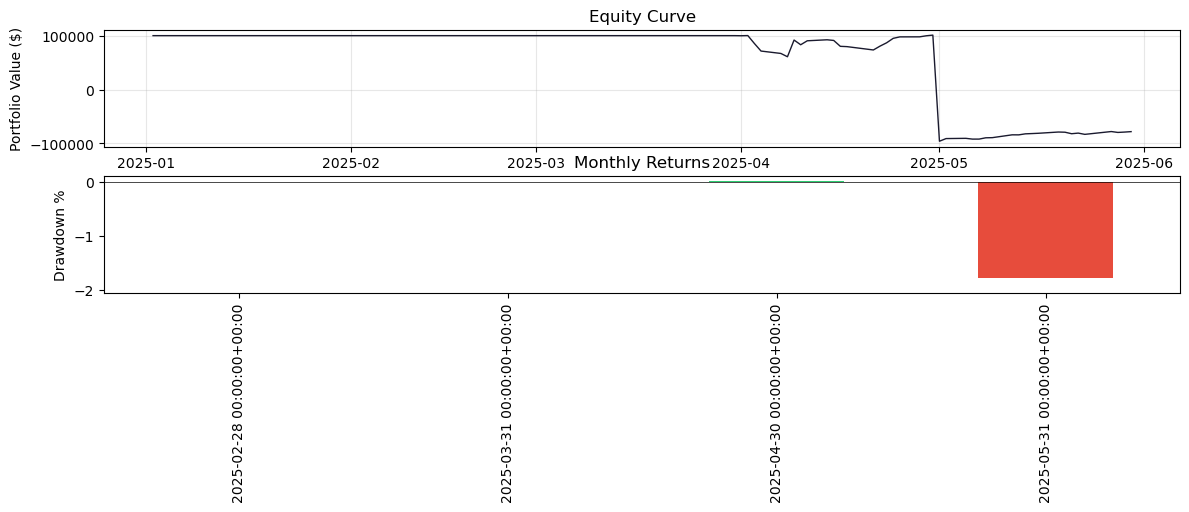

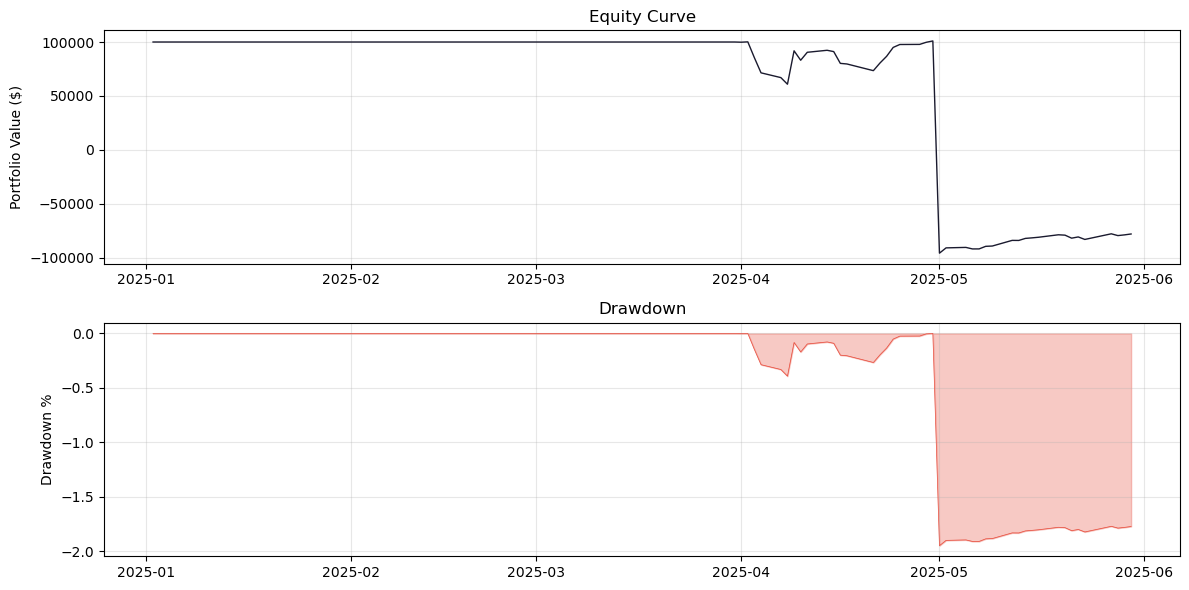

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

eq = result.portfolio.equity_curve
ax1.plot(eq.index, eq.values, color="#1a1a2e", linewidth=1)
ax1.set_title("Equity Curve")
ax1.set_ylabel("Portfolio Value ($)")
ax1.grid(True, alpha=0.3)

rolling_max = eq.expanding().max()
dd = (eq - rolling_max) / rolling_max
ax2.fill_between(dd.index, dd.values, 0, color="#e74c3c", alpha=0.3)
ax2.plot(dd.index, dd.values, color="#e74c3c", linewidth=0.5)
ax2.set_title("Drawdown")
ax2.set_ylabel("Drawdown %")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analyze Performance by Month

Positive months: 25.0%
Best month: 0.99%
Worst month: -177.25%


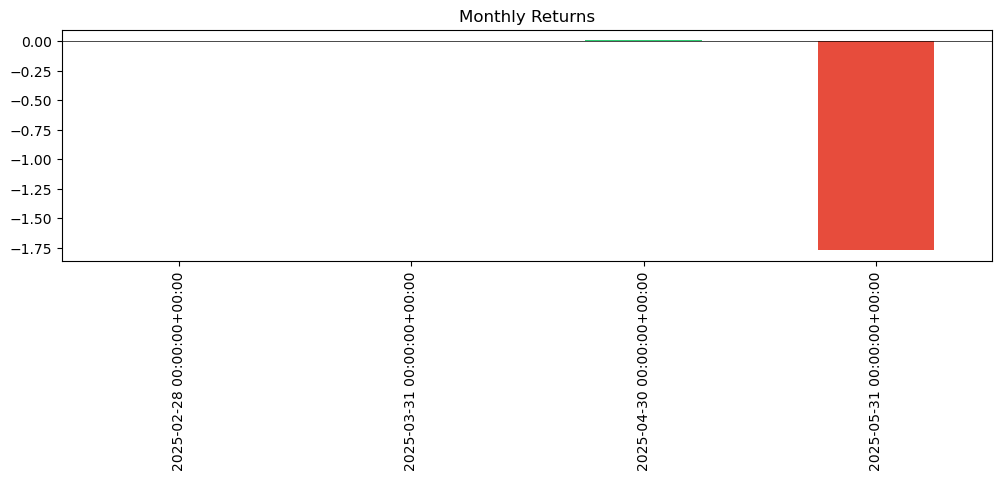

In [18]:
monthly = eq.resample("ME").last().pct_change().dropna()
print(f"Positive months: {(monthly > 0).mean():.1%}")
print(f"Best month: {monthly.max():.2%}")
print(f"Worst month: {monthly.min():.2%}")

monthly.plot(kind="bar", figsize=(12, 3),
             color=["#2ecc71" if v >= 0 else "#e74c3c" for v in monthly])
plt.title("Monthly Returns")
plt.axhline(y=0, color="black", linewidth=0.5)
plt.show()

## 6. Iterate: Try Different Parameters

In [19]:
results = []
for lookback in [40, 60, 90, 120]:
    for top_n in [1, 2, 3]:
        s = MomentumStrategy()
        s.lookback = lookback
        s.top_n = top_n
        r = Engine(cfg).run(s, data)
        m = summary(r)
        results.append({"lookback": lookback, "top_n": top_n,
                        "sharpe": m["sharpe_ratio"],
                        "return": m["annual_return"],
                        "max_dd": m["max_drawdown"]})

df_results = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print("Top 5 parameter combinations:")
display(df_results.head(5).round(3))

Top 5 parameter combinations:


,lookback,top_n,sharpe,return,max_dd
2,40,3,0.96,-6.303,-2.562
6,90,1,0.95,0.207,-0.081
7,90,2,0.65,0.097,-0.062
8,90,3,0.20,0.019,-0.060
10,120,2,0.00,0.000,0.000


## 7. Generate Report

## 7. Walk-Forward Validation

Don't trust in-sample results. Validate out-of-sample.

In [ ]:
# Use the best params from GridSearch above
best = df_results.iloc[0]
strategy = MomentumStrategy()
strategy.lookback = int(best["lookback"])
strategy.top_n = int(best["top_n"])

wf = WalkForward(strategy, data, cfg, train_window="9M", test_window="3M")
oos = wf.summary()

print("Out-of-sample performance (walk-forward):")
for k, v in oos.items():
    if not k.startswith("n_"):
        print(f"  {k}: {v}")

# Check OOS Sharpe consistency
folds = wf.run()
sharpe_by_fold = [f["test_metrics"]["sharpe_ratio"] for f in folds]
print(f"\nOOS Sharpe by fold: {[round(s, 2) for s in sharpe_by_fold]}")
print(f"Mean: {np.mean(sharpe_by_fold):.2f} ± {np.std(sharpe_by_fold):.2f}")

if np.mean(sharpe_by_fold) > 0:
    print("✓ Positive average OOS Sharpe — strategy might be viable")
else:
    print("✗ Negative OOS Sharpe — strategy likely overfit or not predictive")

## 8. Paper Trading Simulation

Route strategy signals through the OMS for realistic execution simulation.

In [21]:
import asyncio
from oms.broker import PaperBroker
from oms.manager import OrderManager
from oms.position import PositionTracker
from oms.alerting import AlertManager, ConsoleHandler
from oms.bridge import convert_signal, forward_signal, reconcile

# Setup
broker = PaperBroker(initial_capital=100_000)
broker.update_price("NVDA", close["NVDA"].iloc[0])
broker.update_price("MSFT", close["MSFT"].iloc[0])
broker.update_price("AAPL", close["AAPL"].iloc[0])
broker.update_price("AMZN", close["AMZN"].iloc[0])
mgr = OrderManager(broker)
pt = PositionTracker(broker)
alerts = AlertManager()
alerts.on_alert(ConsoleHandler())

# Run paper trading for first 50 bars of the backtest period
strategy = MomentumStrategy()
strategy.lookback = int(best["lookback"])
strategy.top_n = int(best["top_n"])

# Create a strategy context manually (same as engine does internally)
from engine.strategy import StrategyContext
from engine.portfolio import Portfolio
pf = Portfolio(initial_capital=100_000)
ctx = StrategyContext(data=data, portfolio=pf, config=cfg)
strategy.on_init(ctx)

print("Running paper trading simulation...")
for bar in range(min(50, len(data))):
    broker.update_price("NVDA", data.close.iloc[bar]["NVDA"])
    broker.update_price("MSFT", data.close.iloc[bar]["MSFT"])
    broker.update_price("AAPL", data.close.iloc[bar]["AAPL"])
    broker.update_price("AMZN", data.close.iloc[bar]["AMZN"])
    
    signals = strategy.on_bar(ctx, bar)
    for sig in signals:
        combined = convert_signal(sig, pf)
        results = forward_signal(combined, broker, mgr, position_tracker=pt)
        if results:
            t = results[0]
            print(f"  bar {bar}: {t.symbol} {t.side} qty={t.filled_qty} state={t.state}")

print(f"\nPaper trading results:")
print(f"  Positions: {pt.positions}")
print(f"  Alerts: {alerts.count_by_level('warning')} warnings")

# Reconcile with engine portfolio
issues = reconcile(ctx.portfolio, pt)
if issues:
    print(f"  Reconciliation issues: {issues}")
else:
    print("  Positions reconciled ✓")

Running paper trading simulation...


RuntimeError: asyncio.run() cannot be called from a running event loop

In [13]:
generate(result, "momentum_strategy_report.html")
print("Report saved to momentum_strategy_report.html")

Report saved to momentum_strategy_report.html


## What We Did

1. Loaded 6 S&P 500 stocks with 2+ years of daily data from GCS backfill
2. Defined a momentum rotation strategy
3. Ran backtest with `engine.run()`
4. Visualized equity curve and drawdown
5. Grid-searched best parameters
6. Validated with walk-forward cross-validation
7. Paper-traded through the OMS pipeline

## Next Steps

- Add risk controls: `self.add_risk(StopLoss(pct=0.05))` in on_init()
- Run live on Alpaca paper: `AlpacaBroker(paper=True)` instead of `PaperBroker`
- Start the dashboard: `uvicorn dashboard.api:app --port 8090`
- Read more: `docs/manual/02-research.md`